In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns",None)

In [2]:
df = pd.read_csv("../data/processed/clean_customer_support_dataset.csv")

print(df.shape)

df.head()

(100000, 23)


,ticket_id,created_at,customer_id,customer_segment,channel,product_area,issue_type,priority,status,sla_plan,initial_message,agent_first_reply,resolution_summary,resolution_time_hours,reopened,customer_sentiment,csat_score,has_attachment,platform,region,message_length,word_count,is_resolved
0,TCKT_000001,2024-01-31 05:14:27,CUST_00861,individual,email,data_export,account_access,low,resolved,standard,i cannot log in the system says my password i...,sorry to hear you re having trouble accessing ...,reset account credentials and confirmed succes...,36.53,0,very_negative,1,0,android,EU,58,11,1
1,TCKT_000002,2024-10-20 06:15:49,CUST_00770,individual,in_app,billing,security_concern,medium,closed_no_action,standard,i noticed a suspicious login on my account.,we take security very seriously. our team is r...,ticket closed without further action after no ...,238.32,0,neutral,3,0,web,Unknown,43,8,1
2,TCKT_000003,2024-06-18 21:35:54,CUST_02559,small_business,chat,api_integration,bug,low,in_progress,standard,the api integration feature is not saving my c...,thanks for reporting this bug. we will look in...,NaN,NaN,0,neutral,3,0,android,MEA,53,9,0
3,TCKT_000004,2025-12-25 15:59:52,CUST_03557,education,chat,analytics_dashboard,account_access,medium,in_progress,standard,i cannot log in the system says my password i...,sorry to hear you re having trouble accessing ...,NaN,NaN,0,positive,5,1,android,LATAM,58,11,0
4,TCKT_000005,2023-08-27 16:08:33,CUST_09556,enterprise,phone_transcript,login_auth,billing_problem,low,resolved,gold,my invoice amount is incorrect compared to the...,thanks for reaching out about the billing issu...,adjusted the invoice and issued a refund where...,61.32,0,very_negative,2,0,web,Unknown,63,11,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ticket_id              100000 non-null  str    
 1   created_at             100000 non-null  str    
 2   customer_id            100000 non-null  str    
 3   customer_segment       100000 non-null  str    
 4   channel                100000 non-null  str    
 5   product_area           100000 non-null  str    
 6   issue_type             100000 non-null  str    
 7   priority               100000 non-null  str    
 8   status                 100000 non-null  str    
 9   sla_plan               100000 non-null  str    
 10  initial_message        100000 non-null  str    
 11  agent_first_reply      100000 non-null  str    
 12  resolution_summary     60113 non-null   str    
 13  resolution_time_hours  60113 non-null   float64
 14  reopened               100000 non-null  int64  


In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ticket_id,100000,100000,TCKT_000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
created_at,100000,99959,2023-06-29 22:03:45,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,100000,9999,CUST_07153,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_segment,100000,5,small_business,20203,NaN,NaN,NaN,NaN,NaN,NaN,NaN
channel,100000,5,phone_transcript,20133,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_area,100000,7,mobile_app,14432,NaN,NaN,NaN,NaN,NaN,NaN,NaN
issue_type,100000,8,how_to,12739,NaN,NaN,NaN,NaN,NaN,NaN,NaN
priority,100000,4,low,39735,NaN,NaN,NaN,NaN,NaN,NaN,NaN
status,100000,5,resolved,50131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sla_plan,100000,3,standard,60066,NaN,NaN,NaN,NaN,NaN,NaN,NaN


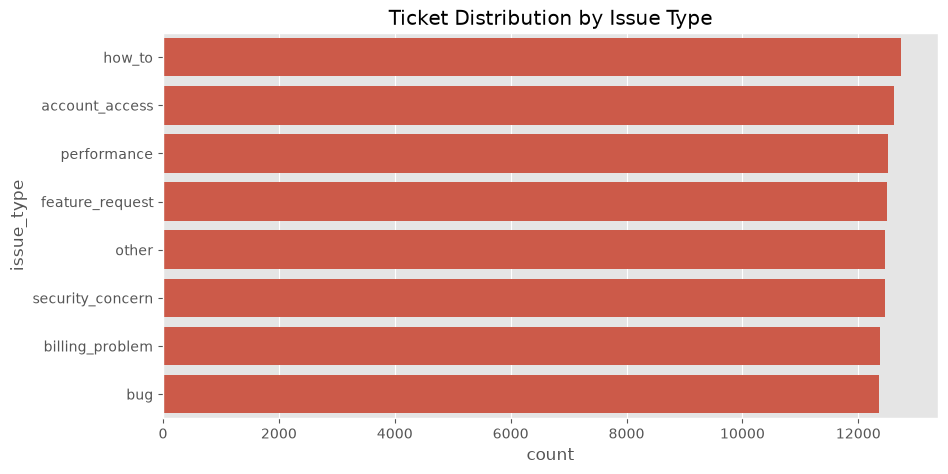

In [5]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    y="issue_type",
    order=df["issue_type"].value_counts().index
)

plt.title("Ticket Distribution by Issue Type")

plt.show()

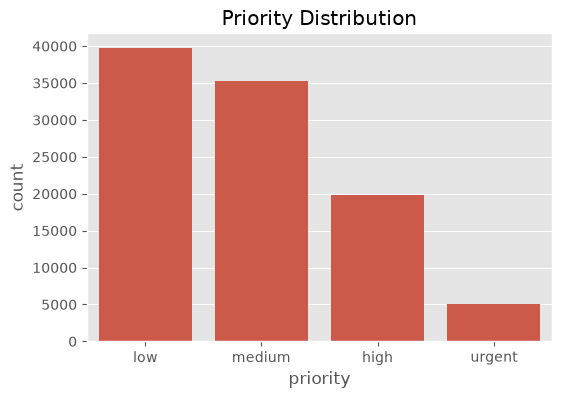

In [6]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="priority",
    order=df["priority"].value_counts().index
)

plt.title("Priority Distribution")

plt.show()

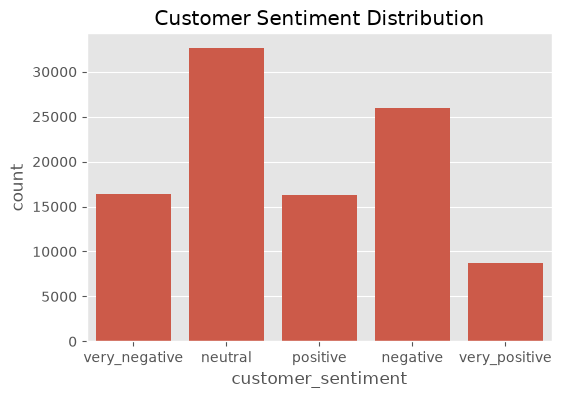

In [7]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="customer_sentiment"
)

plt.title("Customer Sentiment Distribution")

plt.show()

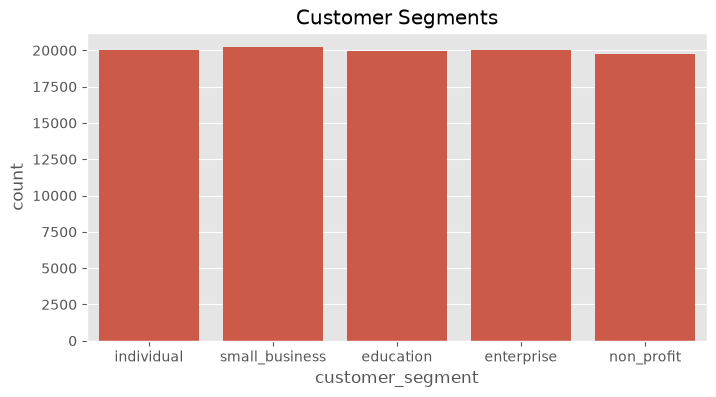

In [8]:
plt.figure(figsize=(8,4))

sns.countplot(
    data=df,
    x="customer_segment"
)

plt.title("Customer Segments")

plt.show()


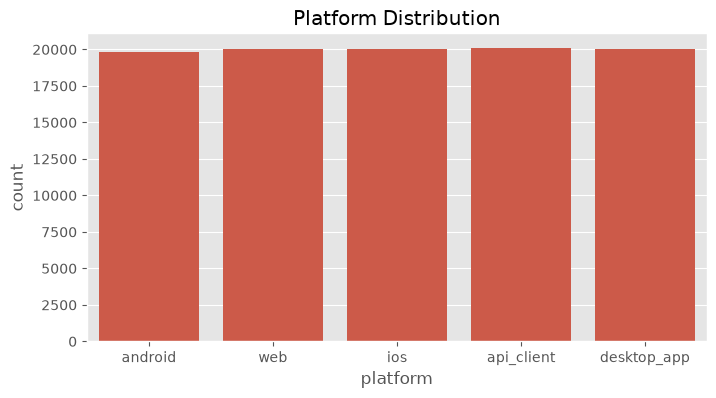

In [9]:
plt.figure(figsize=(8,4))

sns.countplot(
    data=df,
    x="platform"
)

plt.title("Platform Distribution")

plt.show()

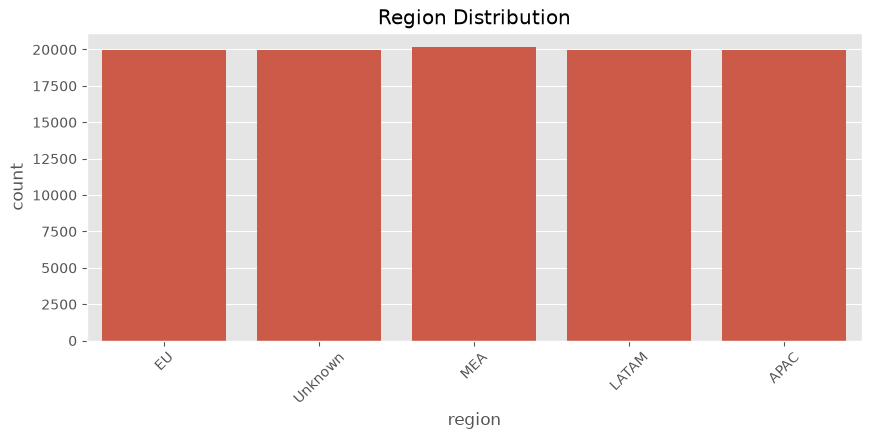

In [10]:
plt.figure(figsize=(10,4))

sns.countplot(
    data=df,
    x="region"
)

plt.xticks(rotation=45)

plt.title("Region Distribution")

plt.show()

In [11]:
resolved = df[df["is_resolved"] == 1]

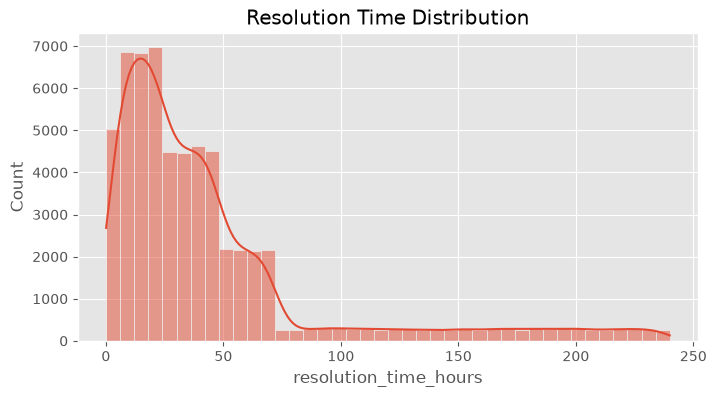

In [12]:
plt.figure(figsize=(8,4))

sns.histplot(
    resolved["resolution_time_hours"],
    bins=40,
    kde=True
)

plt.title("Resolution Time Distribution")

plt.show()

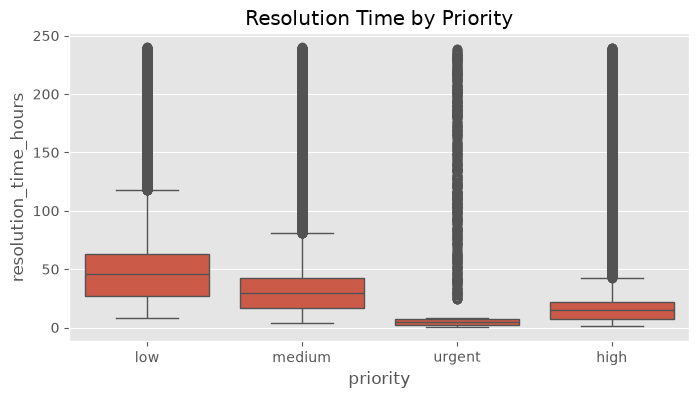

In [13]:
plt.figure(figsize=(8,4))

sns.boxplot(
    data=resolved,
    x="priority",
    y="resolution_time_hours"
)

plt.title("Resolution Time by Priority")

plt.show()

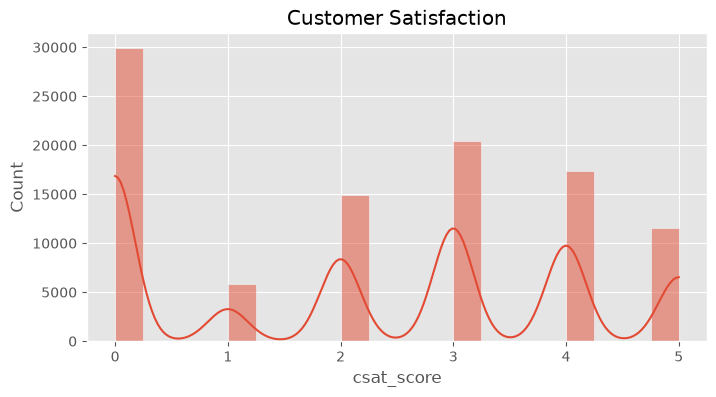

In [14]:
plt.figure(figsize=(8,4))

sns.histplot(
    df["csat_score"],
    bins=20,
    kde=True
)

plt.title("Customer Satisfaction")

plt.show()

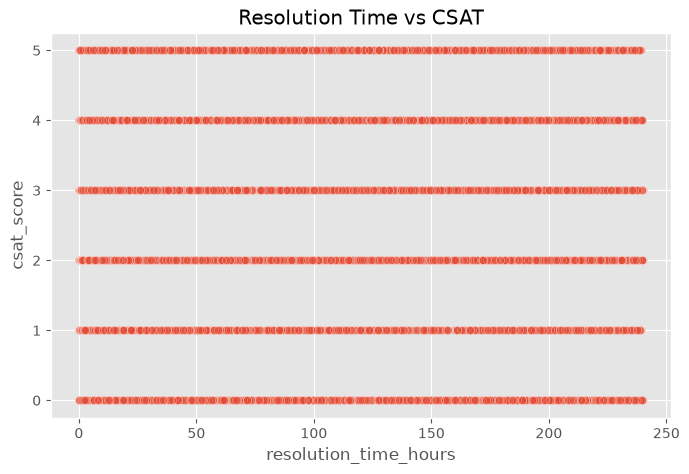

In [15]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=resolved,
    x="resolution_time_hours",
    y="csat_score",
    alpha=0.4
)

plt.title("Resolution Time vs CSAT")

plt.show()

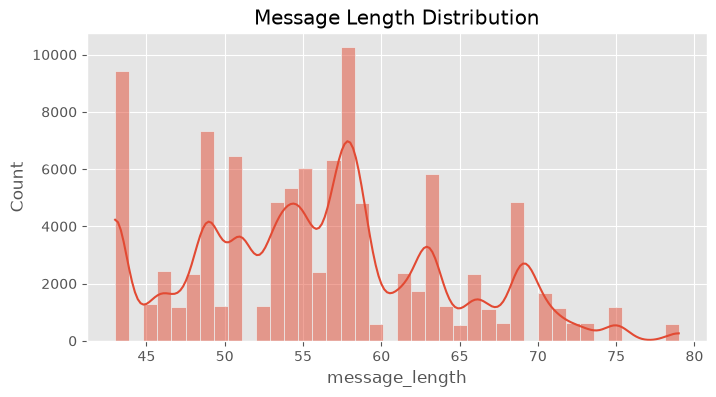

In [16]:
plt.figure(figsize=(8,4))

sns.histplot(
    df["message_length"],
    bins=40,
    kde=True
)

plt.title("Message Length Distribution")

plt.show()

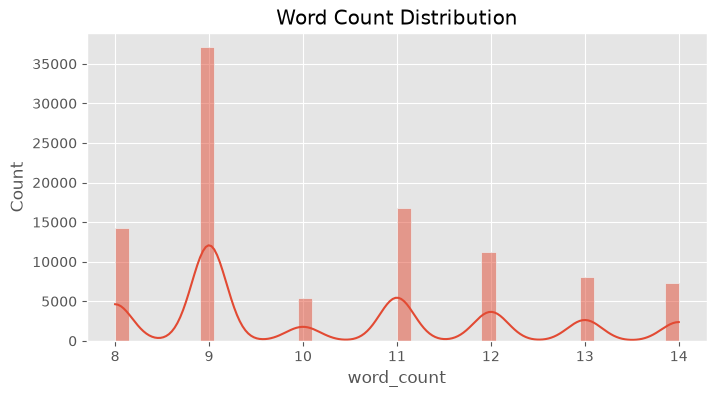

In [17]:
plt.figure(figsize=(8,4))

sns.histplot(
    df["word_count"],
    bins=40,
    kde=True
)

plt.title("Word Count Distribution")

plt.show()

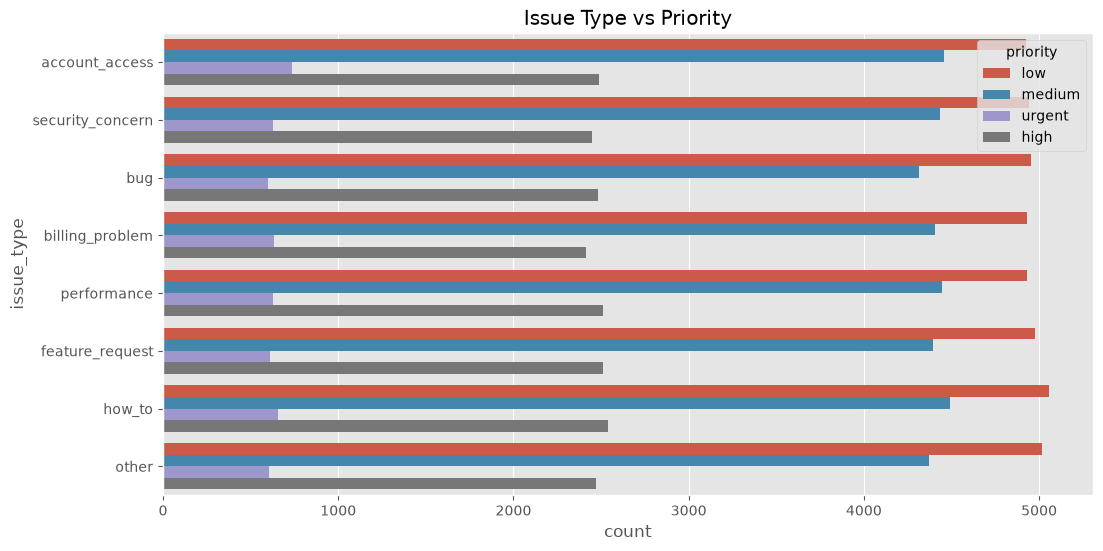

In [18]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="issue_type",
    hue="priority"
)

plt.title("Issue Type vs Priority")

plt.show()

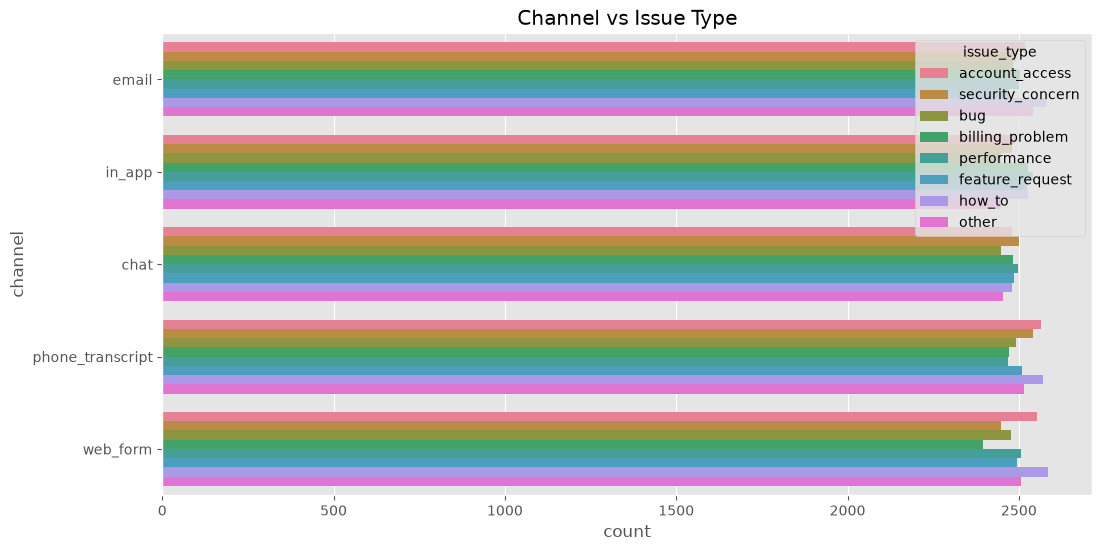

In [19]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="channel",
    hue="issue_type"
)

plt.title("Channel vs Issue Type")

plt.show()

In [20]:
numeric = [
    "message_length",
    "word_count",
    "resolution_time_hours",
    "csat_score",
    "is_resolved"
]

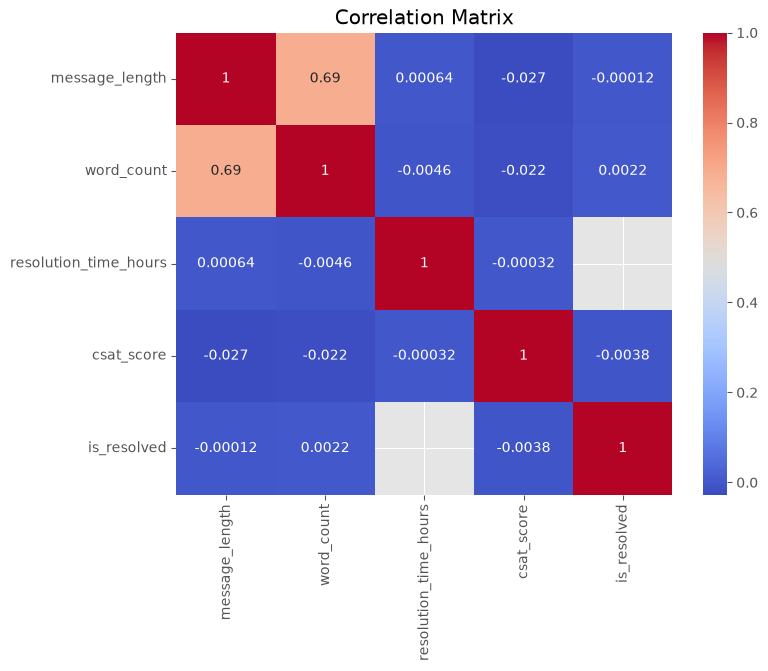

In [21]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[numeric].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [22]:
df["issue_type"].value_counts()

issue_type
how_to              12739
account_access      12609
performance         12513
feature_request     12487
other               12463
security_concern    12458
billing_problem     12382
bug                 12349
Name: count, dtype: int64

In [23]:
df["priority"].value_counts()

priority
low       39735
medium    35313
high      19865
urgent     5087
Name: count, dtype: int64

In [24]:
df["customer_sentiment"].value_counts()

customer_sentiment
neutral          32634
negative         26015
very_negative    16437
positive         16242
very_positive     8672
Name: count, dtype: int64

In [25]:
resolved["resolution_time_hours"].describe()

count    60113.000000
mean        45.013123
std         49.202797
min          0.110000
25%         14.880000
50%         29.910000
75%         51.660000
max        239.960000
Name: resolution_time_hours, dtype: float64